In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

# Kaggle dataset path — always this location
BASE_DIR = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
TRAIN_DIR = f"{BASE_DIR}/train"
VALID_DIR = f"{BASE_DIR}/valid"

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Valid exists:", os.path.exists(VALID_DIR))
print("Classes available:", len(os.listdir(TRAIN_DIR)))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train exists: True
Valid exists: True
Classes available: 38


In [3]:
SELECTED_CLASSES = [
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Grape___Black_rot",
    "Grape___healthy"
]

CONFIG = {
    "train_dir": TRAIN_DIR,
    "valid_dir": VALID_DIR,
    "model_save_path": "/kaggle/working/crop_disease_model.keras",
    "class_names_path": "/kaggle/working/class_names.json",
    "img_size": (224, 224),
    "batch_size": 32,
    "phase1_epochs": 15,
    "phase2_epochs": 20,
    "num_classes": 14
}

os.makedirs("/kaggle/working", exist_ok=True)
print(f"Training on {len(SELECTED_CLASSES)} classes")
print("Config ready")

Training on 14 classes
Config ready


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

# NO rescaling — EfficientNetB0 with imagenet weights needs 0-255 range
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    CONFIG["train_dir"],
    target_size=CONFIG["img_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=True,
    classes=SELECTED_CLASSES
)

valid_generator = valid_datagen.flow_from_directory(
    CONFIG["valid_dir"],
    target_size=CONFIG["img_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=False,
    classes=SELECTED_CLASSES
)

class_names = list(train_generator.class_indices.keys())
with open(CONFIG["class_names_path"], "w") as f:
    json.dump(class_names, f, indent=2)

print(f"Training images  : {train_generator.samples}")
print(f"Validation images: {valid_generator.samples}")
print(f"Classes          : {len(class_names)}")

Found 26664 images belonging to 14 classes.
Found 6667 images belonging to 14 classes.
Training images  : 26664
Validation images: 6667
Classes          : 14


In [5]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
import tensorflow as tf

def build_model(num_classes):
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    # No rescaling — pass raw pixels directly to EfficientNetB0
    # EfficientNetB0 handles its own normalization internally
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs), base_model

def get_callbacks(save_path):
    return [
        EarlyStopping(
            monitor="val_accuracy",
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=save_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        )
    ]

model, base_model = build_model(num_classes=14)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model built — no preprocessing layer")
model.summary()

I0000 00:00:1780220108.036625     745 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model built — no preprocessing layer


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,845,489 (18.48 MB)

 Trainable params: 793,358 (3.03 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [6]:
print("=" * 50)
print("PHASE 1 — Training classification head")
print("Base model frozen — only top layers training")
print("=" * 50)

history_phase1 = model.fit(
    train_generator,
    epochs=CONFIG["phase1_epochs"],
    validation_data=valid_generator,
    callbacks=get_callbacks(CONFIG["model_save_path"]),
    verbose=1
)

print(f"\nPhase 1 complete")
print(f"Best val accuracy: {max(history_phase1.history['val_accuracy']):.4f}")

PHASE 1 — Training classification head
Base model frozen — only top layers training
Epoch 1/15


I0000 00:00:1780220125.704392     820 service.cc:152] XLA service 0x798f0c114800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780220125.704431     820 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780220128.060710     820 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780220138.679977     820 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8231 - loss: 0.5576
Epoch 1: val_accuracy improved from None to 0.97240, saving model to /kaggle/working/crop_disease_model.keras

Epoch 1: finished saving model to /kaggle/working/crop_disease_model.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 374s 421ms/step - accuracy: 0.8964 - loss: 0.3261 - val_accuracy: 0.9724 - val_loss: 0.0892 - learning_rate: 0.0010
Epoch 2/15
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9448 - loss: 0.1788
Epoch 2: val_accuracy improved from 0.97240 to 0.97630, saving model to /kaggle/working/crop_disease_model.keras

Epoch 2: finished saving model to /kaggle/working/crop_disease_model.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 310s 371ms/step - accuracy: 0.9482 - loss: 0.1653 - val_accuracy: 0.9763 - val_loss: 0.0783 - learning_rate: 0.0010
Epoch 3/15
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9573 - loss: 0.1421
Epoch 3: val_accuracy did not improve from 0.97630
834/834 ━━━━━━━━━━━━━━━━━━━━ 31

In [7]:
print("=" * 50)
print("PHASE 2 — Fine-tuning top 30 layers")
print("=" * 50)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase2 = model.fit(
    train_generator,
    epochs=CONFIG["phase2_epochs"],
    validation_data=valid_generator,
    callbacks=get_callbacks(CONFIG["model_save_path"]),
    verbose=1
)

print(f"\nPhase 2 complete")
print(f"Best val accuracy: {max(history_phase2.history['val_accuracy']):.4f}")

PHASE 2 — Fine-tuning top 30 layers
Epoch 1/20


2026-05-31 10:56:35.050043: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 10:56:35.256729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 10:56:35.674432: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 10:56:35.880763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


677/834 ━━━━━━━━━━━━━━━━━━━━ 56s 358ms/step - accuracy: 0.9282 - loss: 0.2745

2026-05-31 11:00:50.889931: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 11:00:51.094613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9303 - loss: 0.2644
Epoch 1: val_accuracy improved from None to 0.97375, saving model to /kaggle/working/crop_disease_model.keras

Epoch 1: finished saving model to /kaggle/working/crop_disease_model.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 365s 405ms/step - accuracy: 0.9408 - loss: 0.2134 - val_accuracy: 0.9738 - val_loss: 0.0805 - learning_rate: 1.0000e-05
Epoch 2/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9575 - loss: 0.1395
Epoch 2: val_accuracy improved from 0.97375 to 0.98050, saving model to /kaggle/working/crop_disease_model.keras

Epoch 2: finished saving model to /kaggle/working/crop_disease_model.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 310s 372ms/step - accuracy: 0.9601 - loss: 0.1323 - val_accuracy: 0.9805 - val_loss: 0.0575 - learning_rate: 1.0000e-05
Epoch 3/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9648 - loss: 0.1233
Epoch 3: val_accuracy improved from 0.98050 to 0.98455, saving model to /k

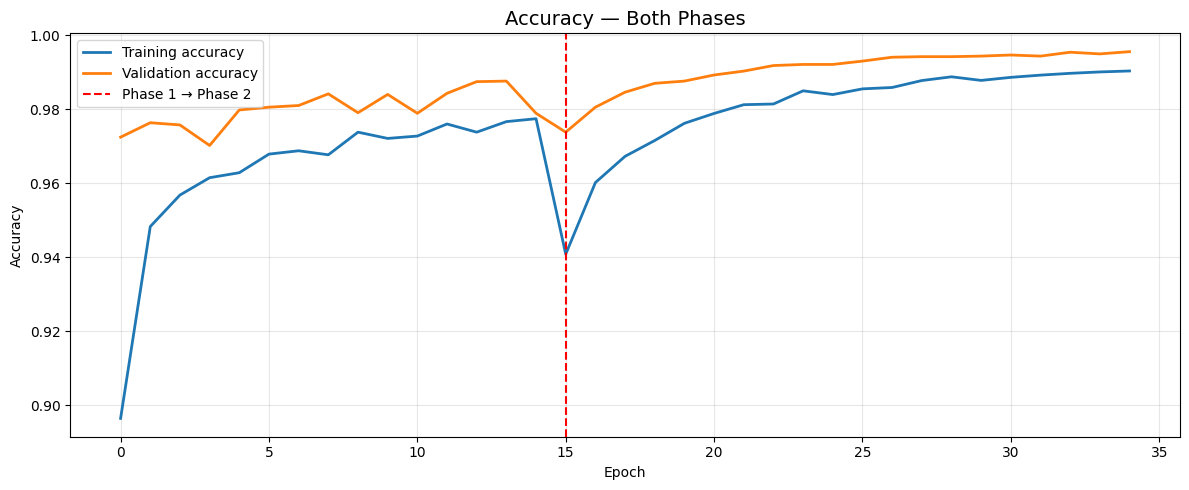

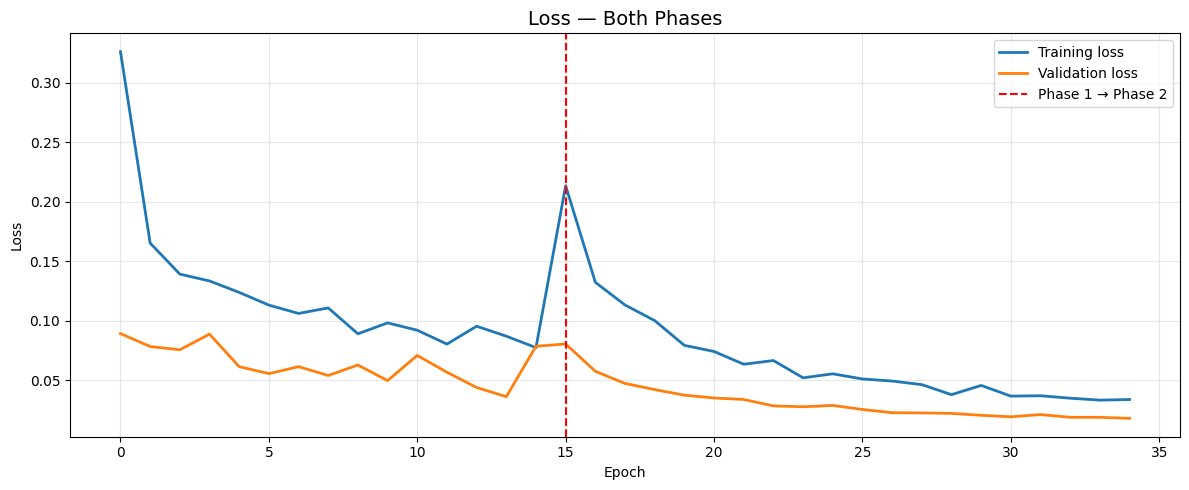

In [8]:
def plot_history(h1, h2, metric="accuracy"):
    values = h1.history[metric] + h2.history[metric]
    val_values = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
    phase1_end = len(h1.history[metric])

    plt.figure(figsize=(12, 5))
    plt.plot(values, label=f"Training {metric}", linewidth=2)
    plt.plot(val_values, label=f"Validation {metric}", linewidth=2)
    plt.axvline(x=phase1_end, color="red",
                linestyle="--", label="Phase 1 → Phase 2")
    plt.title(f"{metric.capitalize()} — Both Phases", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/training_{metric}.png", dpi=150)
    plt.show()

plot_history(history_phase1, history_phase2, "accuracy")
plot_history(history_phase1, history_phase2, "loss")

In [9]:
best_model = tf.keras.models.load_model(CONFIG["model_save_path"])

valid_generator.reset()
y_pred_probs = best_model.predict(valid_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = valid_generator.classes

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
))
print(f"Overall Accuracy: {np.mean(y_pred == y_true):.4f}")

209/209 ━━━━━━━━━━━━━━━━━━━━ 25s 91ms/step
CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

              Tomato___Early_blight     0.9895    0.9812    0.9854       480
               Tomato___Late_blight     0.9745    0.9914    0.9829       463
                   Tomato___healthy     0.9979    0.9979    0.9979       481
        Corn_(maize)___Common_rust_     1.0000    0.9979    0.9990       477
Corn_(maize)___Northern_Leaf_Blight     0.9979    1.0000    0.9990       477
             Corn_(maize)___healthy     1.0000    1.0000    1.0000       465
                 Apple___Apple_scab     1.0000    0.9841    0.9920       504
                  Apple___Black_rot     0.9920    1.0000    0.9960       497
                    Apple___healthy     0.9901    1.0000    0.9950       502
              Potato___Early_blight     0.9979    1.0000    0.9990       485
               Potato___Late_blight     1.0000    0.9876    0.9938       485
          

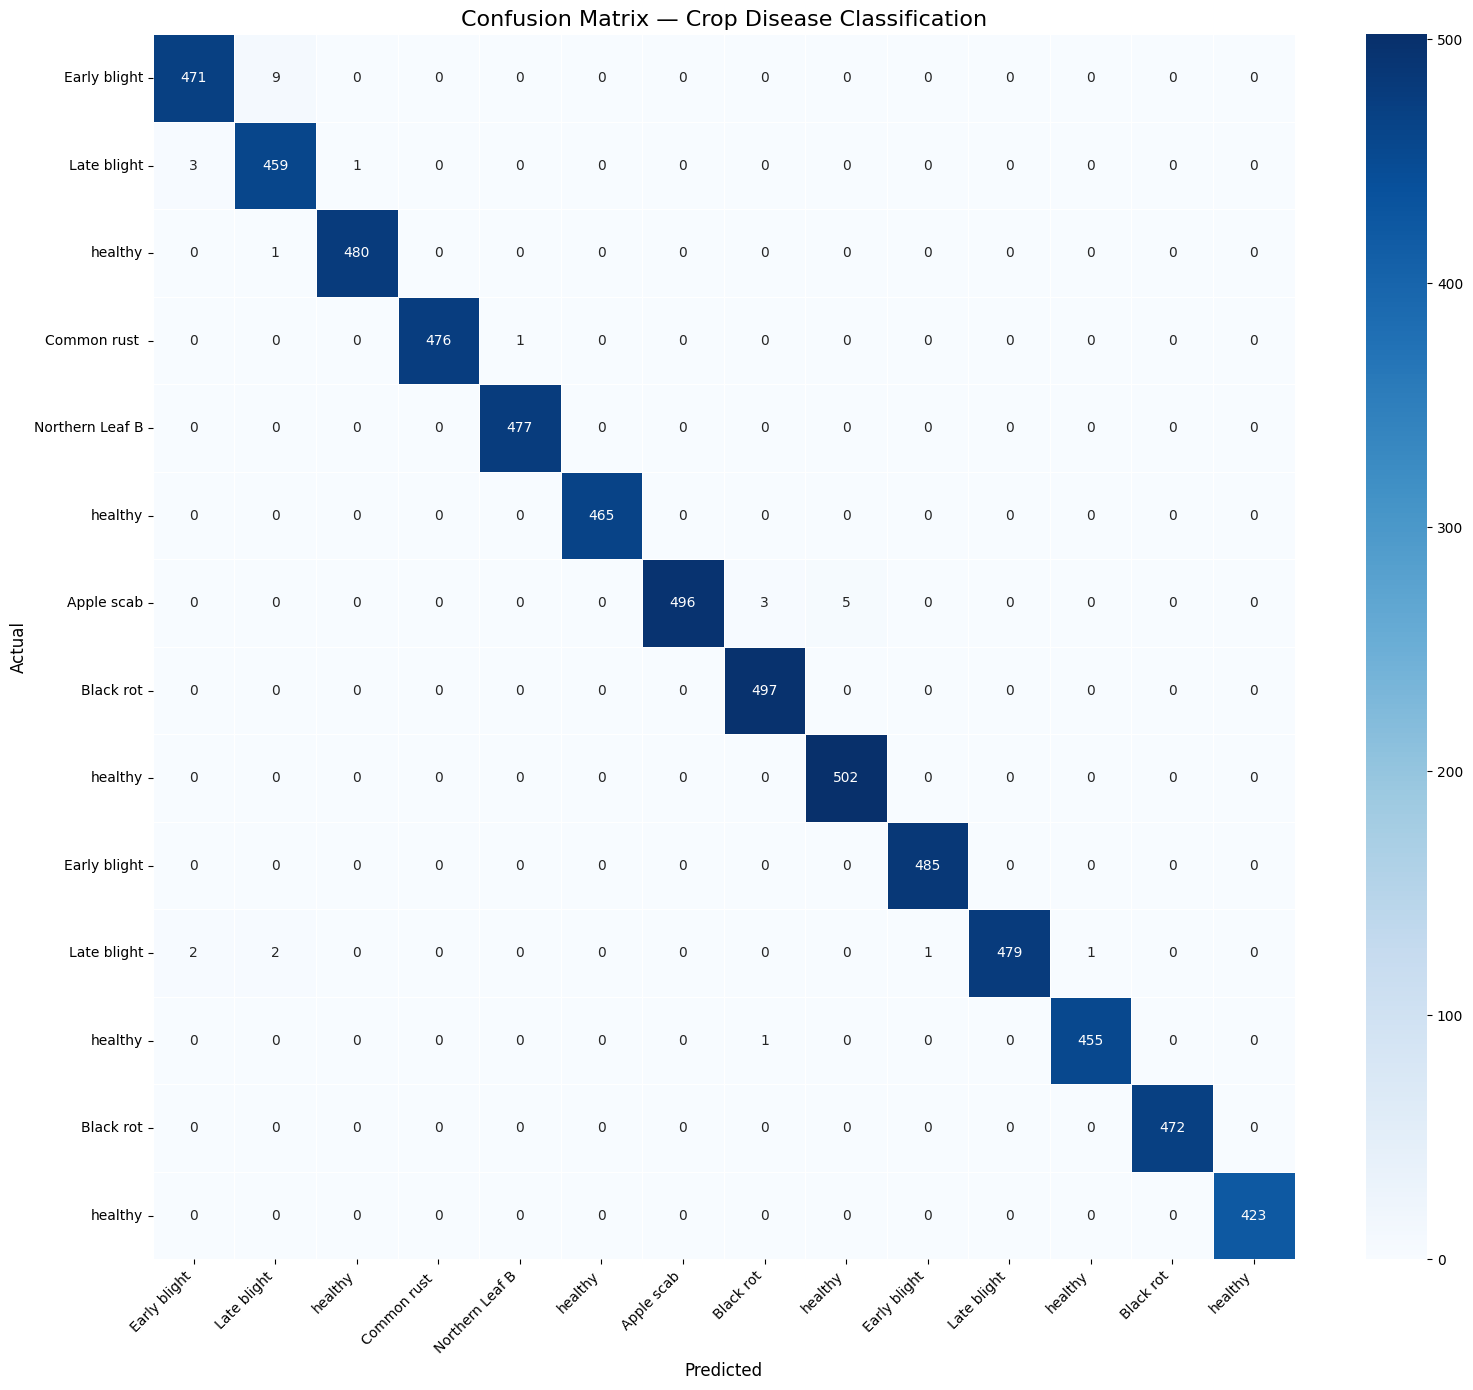

In [10]:
cm = confusion_matrix(y_true, y_pred)
short_names = [c.split("___")[-1].replace("_", " ")[:15] for c in class_names]

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.5
)
plt.title("Confusion Matrix — Crop Disease Classification", fontsize=16)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

In [11]:
import shutil

# Verify model saved
print("Model saved:", os.path.exists(CONFIG["model_save_path"]))
print("Class names saved:", os.path.exists(CONFIG["class_names_path"]))

# List all output files
print("\nFiles in /kaggle/working:")
for f in os.listdir("/kaggle/working"):
    size = os.path.getsize(f"/kaggle/working/{f}") / (1024*1024)
    print(f"  {f} — {size:.2f} MB")

print("\nDone. Download model and class_names.json from Output tab.")

Model saved: True
Class names saved: True

Files in /kaggle/working:
  confusion_matrix.png — 0.14 MB
  .virtual_documents — 0.00 MB
  training_accuracy.png — 0.08 MB
  crop_disease_model.keras — 36.80 MB
  training_loss.png — 0.08 MB
  class_names.json — 0.00 MB

Done. Download model and class_names.json from Output tab.
